In [4]:
# Loading the required datasets 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Importing the datasest

In [5]:
M_food_prices = pd.read_csv("wfp_market_food_prices.csv", on_bad_lines='error')

In [6]:
M_food_prices.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,612035.000000,612035.000000,612035.000000,612035.000000,612035.000000,612034.000000,612034.000000,612034.000000,612034.000000,6.120340e+05
mean,142.686428,11254.992749,849.863812,158.700132,54.460397,14.927718,9.690055,6.396525,2012.312955,3.811781e+03
std,56.403162,18634.362224,494.039910,119.280848,21.693574,0.286900,11.197979,3.436530,3.677556,5.999491e+04
min,1.000000,0.000000,101.000000,50.000000,23.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,108.000000,1497.000000,422.000000,67.000000,28.000000,15.000000,5.000000,3.000000,2011.000000,5.778000e+01
50%,152.000000,1934.000000,892.000000,101.000000,61.000000,15.000000,5.000000,6.000000,2013.000000,2.060000e+02
75%,196.000000,21969.000000,1087.000000,227.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,6.000000e+02
max,238.000000,112869.000000,2094.000000,490.000000,95.000000,18.000000,97.000000,12.000000,2017.000000,5.833333e+06


In [9]:
# Changing the column name to something more meaningful

M_food_prices.rename(columns={
    'adm0_id': 'country_id',
    'adm0_name': 'country_name',
    'adm1_id': 'region_id',
    'adm1_name': 'region_name',
    'mkt_id': 'market_id',
    'cm_id': 'commodity_id',
    'cur_id': 'currency_id',
    'pt_id': 'price_type_id',
    'um_id': 'unit_measure_id',
    'mp_month': 'price_month',
    'mp_year': 'price_year',
    'mp_price': 'price'
}, inplace=True)



## Filtering Dataset for my data

In [10]:
M_food_prices = M_food_prices[M_food_prices['country_name'].isin(['India', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bhutan', 'Bangladesh'])]
M_food_prices.sample(20)

,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
213946,115,India,1495,Kerala,968,Tiruvanantapuram,228,Oil (mustard),68,INR,15.0,Retail,5.0,KG,8.0,2014.0,132.00,"M/o Consumer Affairs, Food and Public Distribu..."
391443,175,Nepal,2153,Eastern,647,Dhankuta,52,Rice,62,NPR,15.0,Retail,5.0,KG,7.0,2001.0,16.25,"ABPMDD, MoAD"
194094,115,India,1510,Uttar Pradesh,952,Lucknow,83,Potatoes,68,INR,15.0,Retail,5.0,KG,7.0,2013.0,16.83,"M/o Consumer Affairs, Food and Public Distribu..."
192507,115,India,1511,West Bengal,950,Kolkata,332,Lentils (urad),68,INR,15.0,Retail,5.0,KG,3.0,2017.0,87.23,"M/o Consumer Affairs, Food and Public Distribu..."
189035,115,India,1510,Uttar Pradesh,947,Kanpur,61,Lentils (masur),68,INR,15.0,Retail,5.0,KG,4.0,2017.0,68.00,"M/o Consumer Affairs, Food and Public Distribu..."
210677,115,India,40424,NaN,965,Srinagar,52,Rice,68,INR,15.0,Retail,5.0,KG,9.0,2011.0,22.00,"M/o Consumer Affairs, Food and Public Distribu..."
213830,115,India,1495,Kerala,968,Tiruvanantapuram,228,Oil (mustard),68,INR,15.0,Retail,5.0,KG,10.0,2003.0,80.00,"M/o Consumer Affairs, Food and Public Distribu..."
204414,115,India,1491,Gujarat,959,Rajkot,463,Milk (pasteurized),68,INR,15.0,Retail,15.0,L,1.0,2017.0,48.00,"M/o Consumer Affairs, Food and Public Distribu..."
217317,115,India,1484,Andaman and Nicobar,1392,Port Blair,58,Wheat flour,68,INR,15.0,Retail,5.0,KG,2.0,2013.0,39.00,"M/o Consumer Affairs, Food and Public Distribu..."
608240,231,Sri Lanka,2736,Central,1915,Matale,58,Wheat flour,55,LKR,15.0,Retail,5.0,KG,12.0,2015.0,84.65,Hector Kobbekaduwa Agrarian Research & Trainin...


## Identifying any missing values in the data set

In [11]:

missing_values = M_food_prices.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 country_id               0
country_name             0
region_id                0
region_name           2716
market_id                0
mkt_name                 0
commodity_id             0
cm_name                  0
currency_id              0
cur_name                 0
price_type_id            0
pt_name                  0
unit_measure_id          0
um_name                  0
price_month              0
price_year               0
price                    0
mp_commoditysource       0
dtype: int64


## Removing any duplicate entries in the data

In [12]:
M_food_prices_cleaned = M_food_prices.drop_duplicates()

## Summary of duplicate entries vs original data
No duplicate values were found in the dataset

In [13]:
print(len(M_food_prices_cleaned))
print(len(M_food_prices))
M_food_prices_cleaned.head(5)

83569
83569


,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
12663,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,12.0,2006.0,23.0,Website of Department of Agricultural Marketing
12664,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,1.0,2007.0,25.5,Website of Department of Agricultural Marketing
12665,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,2.0,2007.0,25.5,Website of Department of Agricultural Marketing
12666,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,3.0,2007.0,26.0,Website of Department of Agricultural Marketing
12667,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,4.0,2007.0,26.0,Website of Department of Agricultural Marketing


# Visualizations

Let us see how the prices for commodities are changing year over year across all the countries.

In [14]:
M_food_prices_cleaned['date'] = pd.to_datetime(M_food_prices_cleaned[['price_year', 'price_month']].rename(columns={'price_year': 'year', 'price_month': 'month'}).assign(day=1))

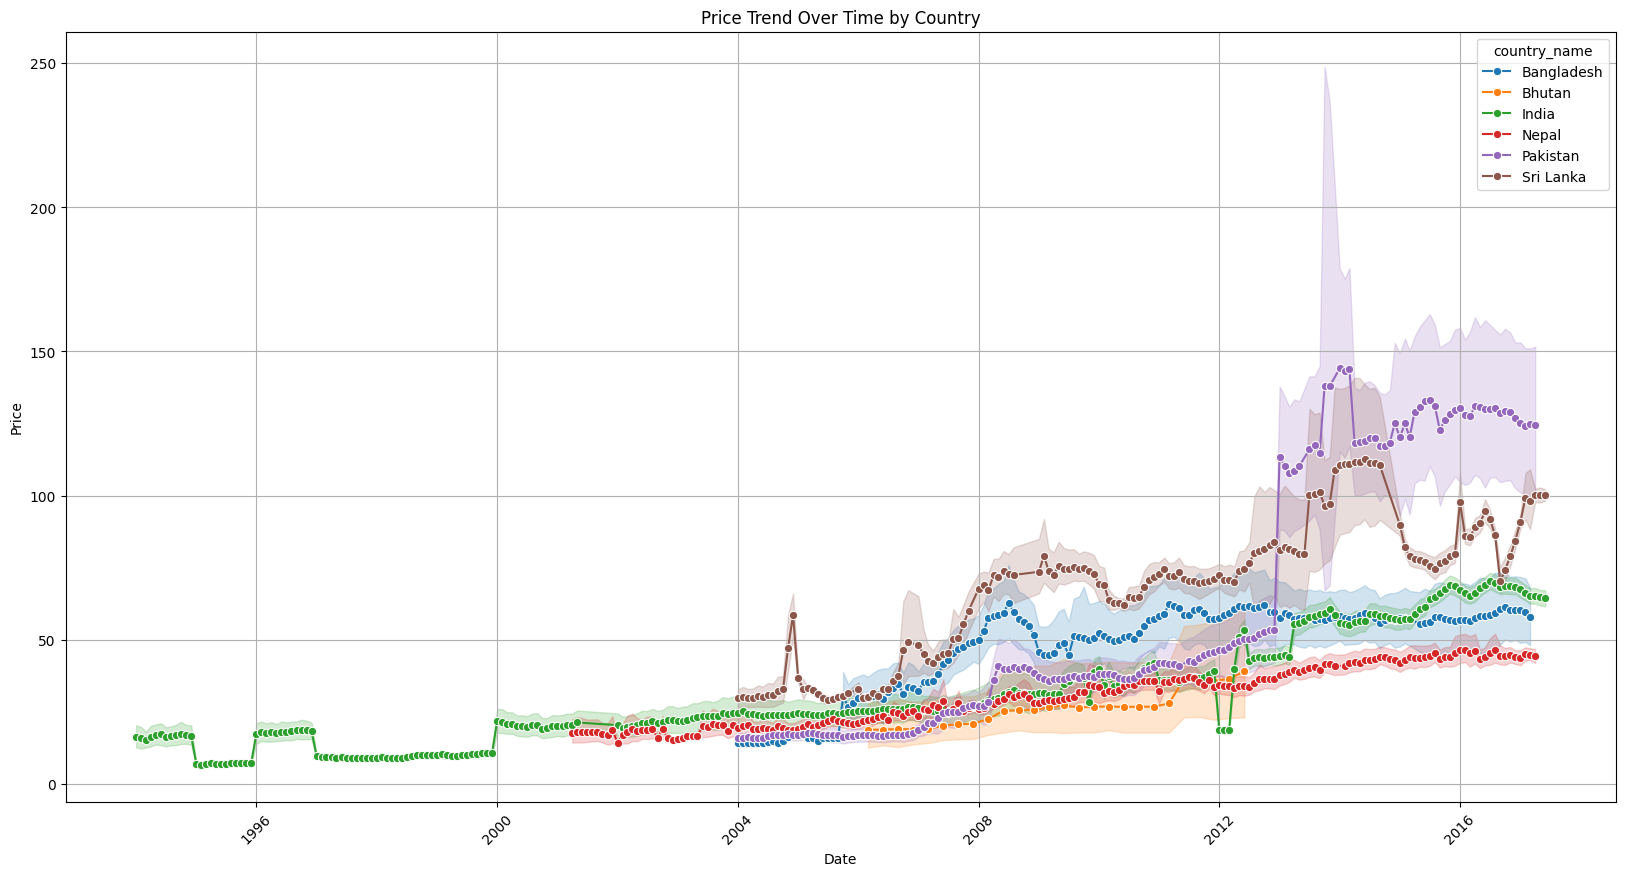

In [15]:
# Plot the data
plt.figure(figsize=(20,10))
sns.lineplot(data=M_food_prices_cleaned, x='date', y='price', hue='country_name', marker="o")

plt.title('Price Trend Over Time by Country')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Observations 

1. We can see that for most of the countries the price tracking started only after 2004. 
2. Pakistan saw a meteoric rise in prices compared to the other countries.
3. Since the prices are non-standard, this won't give us a clear picture of how they compare to each other


## Converting all the currency to USD from the native currency

Note: We are not accounting for the currency fluctuations over time and we take the latest currency values.

In [16]:
currency_conversion = {
    'BDT': 0.0091,   # Bangladeshi Taka to USD
    'BTN': 0.012,    # Bhutanese Ngultrum to USD (same as INR)
    'INR': 0.012,    # Indian Rupee to USD
    'NPR': 0.0075,   # Nepalese Rupee to USD
    'PKR': 0.0036,   # Pakistani Rupee to USD
    'LKR': 0.0031    # Sri Lankan Rupee to USD
}

In [17]:
# Function to convert prices to USD
def convert_to_usd(price, currency_code):
    if currency_code in currency_conversion:
        return price * currency_conversion[currency_code]
    else:
        return price  # If no conversion rate, leave the price unchanged

In [18]:
# Applying the conversion to the DataFrame
# Apply the conversion to the DataFrame
M_food_prices_cleaned['price_usd'] = M_food_prices_cleaned.apply(lambda row: convert_to_usd(row['price'], row['cur_name']), axis=1)

## Visualising the converted currency data

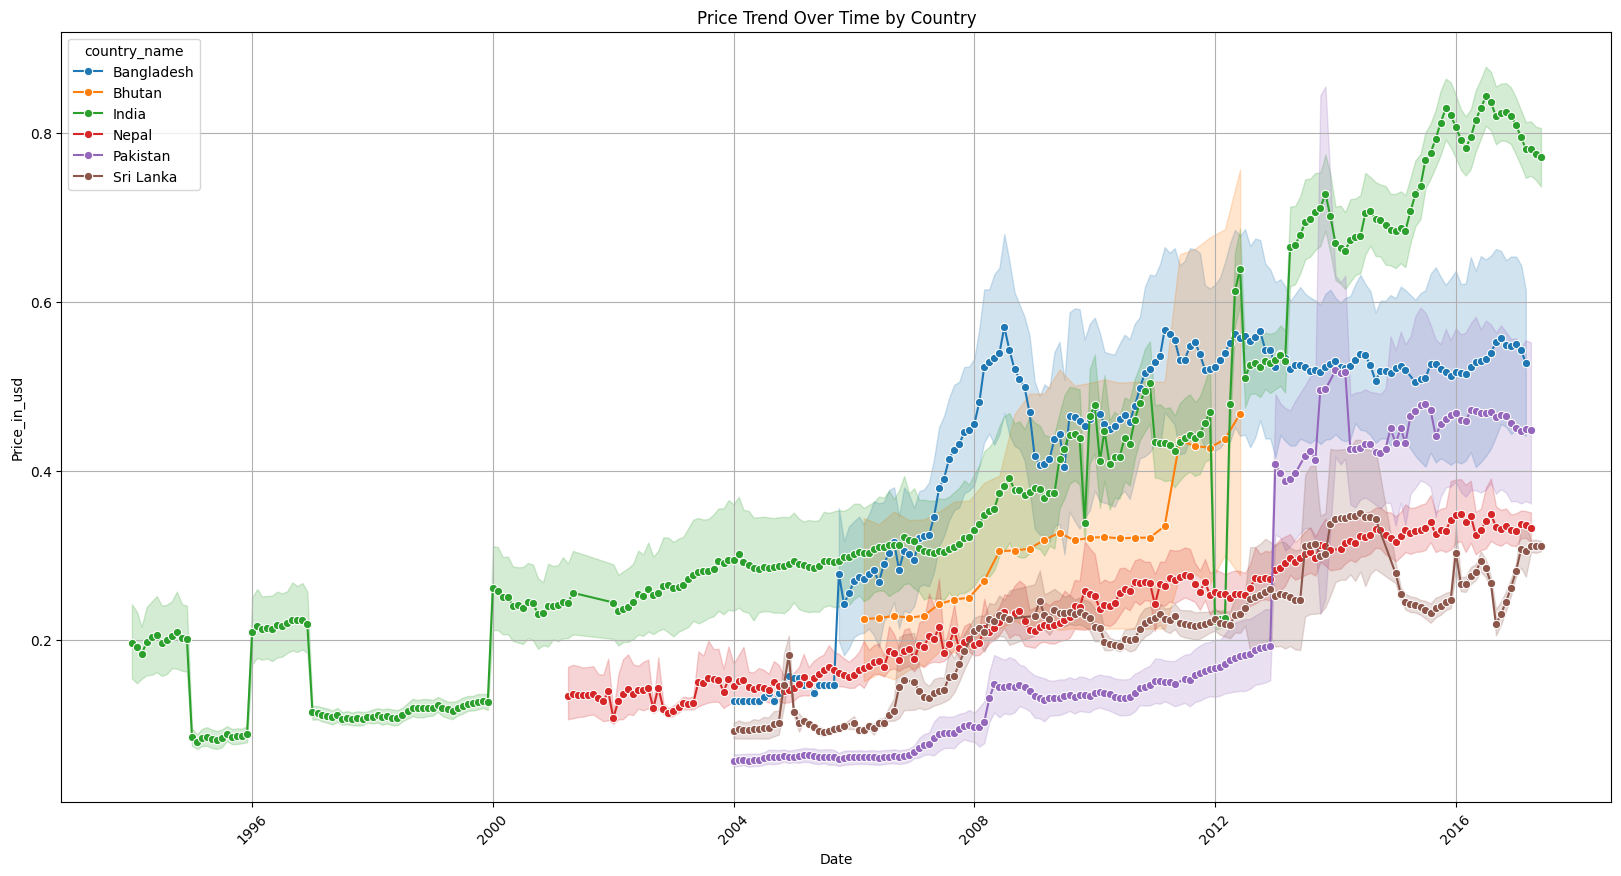

In [19]:
# Plot the data
plt.figure(figsize=(20,10))
sns.lineplot(data=M_food_prices_cleaned, x='date', y='price_usd', hue='country_name', marker="o")

plt.title('Price Trend Over Time by Country')
plt.xlabel('Date')
plt.ylabel('Price_in_usd')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observations

We can observe that after standardizing the prices to USD, there is no longer a country with a drastic increase in price, most countries exhibit similar trend where the prices are steadily increasing.

## Detect Outliers using box plots

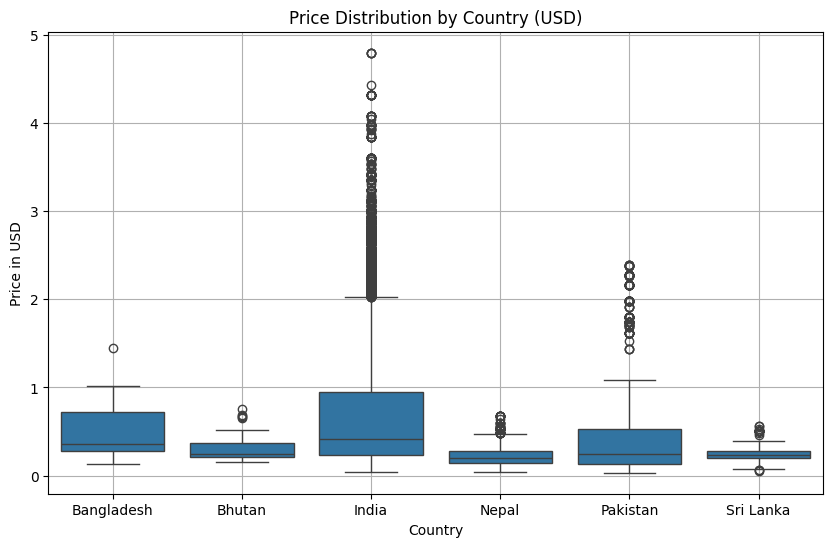

In [20]:
# Plot the boxplot to detect outliers
plt.figure(figsize=(10,6))
sns.boxplot(x='country_name', y='price_usd', data=M_food_prices_cleaned)

plt.title('Price Distribution by Country (USD)')
plt.xlabel('Country')
plt.ylabel('Price in USD')
plt.grid(True)
plt.show()

## Observations
We can see that there are many outliers in Country "India".

Pearson correlation coefficient: 0.3243385693983052
P-value: 0.0


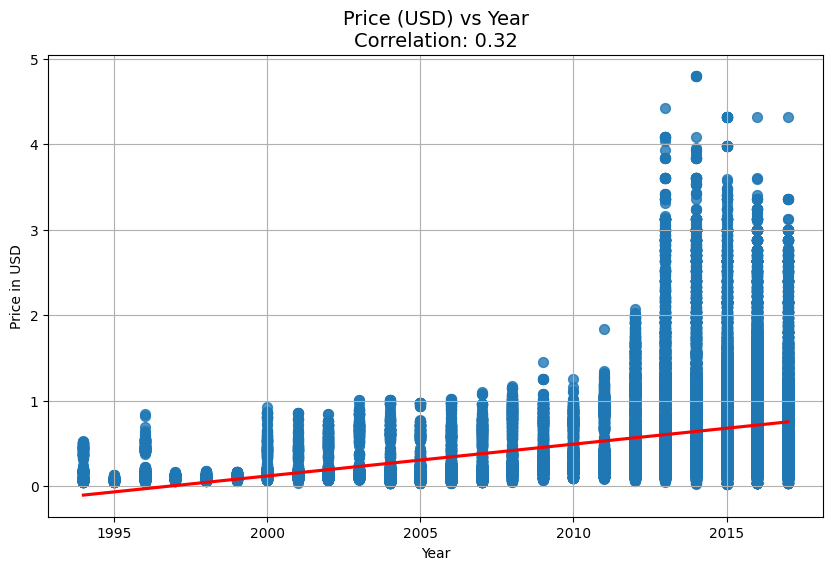

In [21]:
# Calculate Pearson correlation coefficient between price_year and price_usd
correlation, p_value = pearsonr(M_food_prices_cleaned['price_year'], M_food_prices_cleaned['price_usd'])
print(f"Pearson correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

# Scatter plot with a regression line to show the relationship between year and price
plt.figure(figsize=(10,6))
sns.regplot(x='price_year', y='price_usd', data=M_food_prices_cleaned, scatter_kws={'s':50}, line_kws={'color':'red'})

# Customize the plot
plt.title(f'Price (USD) vs Year\nCorrelation: {correlation:.2f}', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.grid(True)
plt.show()

# Observations 

We see that there is a medium strong correlation between the price and the year.

## Checking retail vs wholesale data

In [22]:
# Separate retail and wholesale data
retail_data = M_food_prices_cleaned[M_food_prices_cleaned['pt_name'] == 'Retail']
wholesale_data = M_food_prices_cleaned[M_food_prices_cleaned['pt_name'] == 'Wholesale']


### Calculating average prices

In [23]:
# Calculate the average retail and wholesale prices by commodity
avg_retail_prices = retail_data.groupby('cm_name')['price_usd'].mean().reset_index()
avg_wholesale_prices = wholesale_data.groupby('cm_name')['price_usd'].mean().reset_index()

# Merge retail and wholesale average prices into a single DataFrame
price_comparison = avg_retail_prices.merge(avg_wholesale_prices, on='cm_name', suffixes=('_retail', '_wholesale'))


Checking for one particular staple commodity like Wheat and plotting the price over time

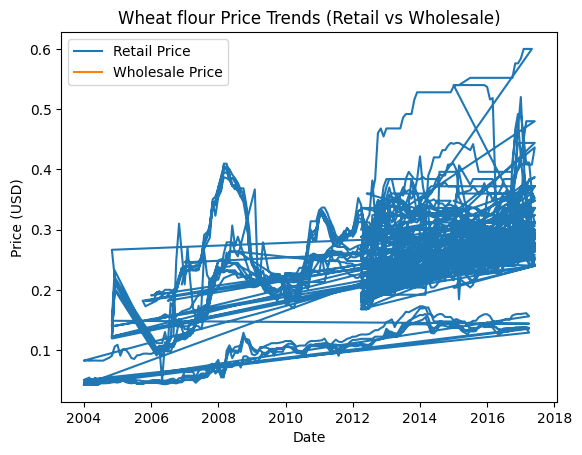

In [24]:
# Filter data for a specific commodity
commodity = 'Wheat flour'
retail_commodity = retail_data[retail_data['cm_name'] == commodity]
wholesale_commodity = wholesale_data[wholesale_data['cm_name'] == commodity]

# Plotting price trends over time
plt.plot(retail_commodity['date'], retail_commodity['price_usd'], label='Retail Price')
plt.plot(wholesale_commodity['date'], wholesale_commodity['price_usd'], label='Wholesale Price')

plt.title(f'{commodity} Price Trends (Retail vs Wholesale)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

Checking for Rice which is a Staple of the region

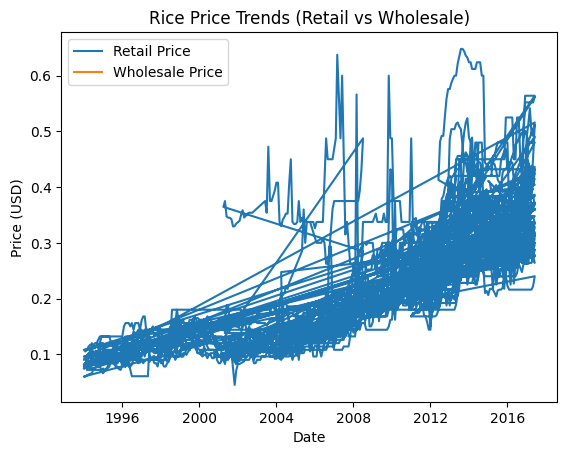

In [26]:

# Filter data for a specific commodity
commodity = 'Rice'
retail_commodity = retail_data[retail_data['cm_name'] == commodity]
wholesale_commodity = wholesale_data[wholesale_data['cm_name'] == commodity]

# Plotting price trends over time
plt.plot(retail_commodity['date'], retail_commodity['price_usd'], label='Retail Price')
plt.plot(wholesale_commodity['date'], wholesale_commodity['price_usd'], label='Wholesale Price')

plt.title(f'{commodity} Price Trends (Retail vs Wholesale)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Observations

There is no wholesale data for these commodities but we can see that the price is increasing over time.

### Region-wise price plot for India

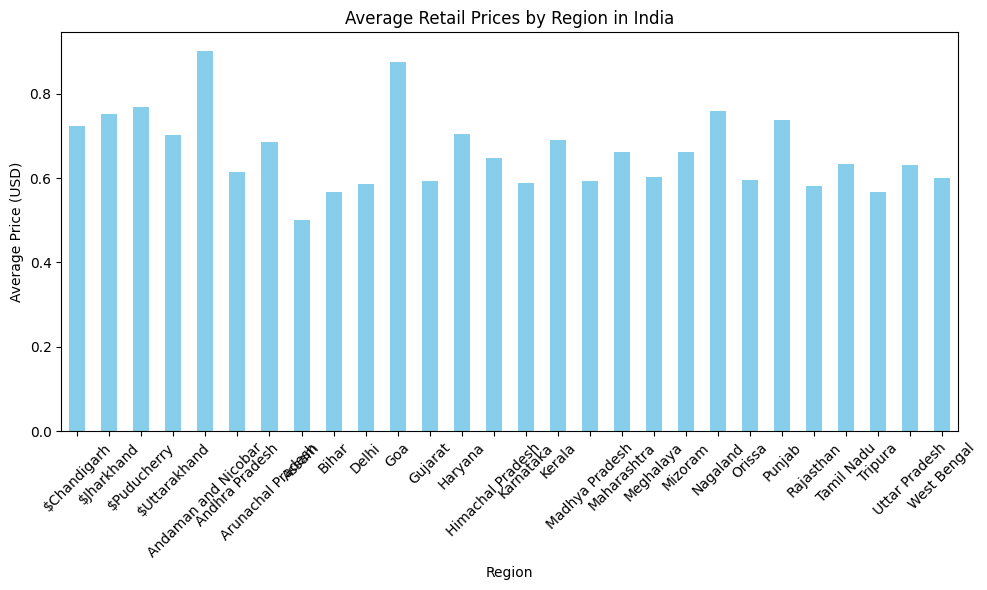

In [36]:
# Assuming M_food_prices_cleaned is your DataFrame and is already loaded

# Normalize pt_name column (if not already done)
M_food_prices_cleaned['pt_name'] = M_food_prices_cleaned['pt_name'].str.strip().str.lower()

# Filter the DataFrame for India
india_data = M_food_prices_cleaned[M_food_prices_cleaned['country_name'] == 'India']

# Separate retail data for India
retail_data = india_data[india_data['pt_name'] == 'retail']

# Calculate the average retail prices by region for India
avg_retail_prices = retail_data.groupby('region_name')['price_usd'].mean().reset_index()

# Rename the column for clarity
avg_retail_prices.rename(columns={'price_usd': 'avg_price_retail'}, inplace=True)

# Plotting the average retail prices by region in India
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot for average retail prices by region
avg_retail_prices.set_index('region_name')['avg_price_retail'].plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Average Retail Prices by Region in India')
ax.set_ylabel('Average Price (USD)')
ax.set_xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()